In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Data imports #

# Imports for plot c
s_profs=np.load('s_test.npy',allow_pickle=True) # this is s not rho
# s_profs=np.broadcast_to(s_profs[None,...],(2,len(s_profs)))
omega_zetas=np.load('freq_test.npy',allow_pickle=True)

# Imports for Poincares
etas_all_KE0 = np.load('poinc_QSbreak_test_etas0.npy',allow_pickle=True)
etas_all_KE1 = np.load('poinc_noQSbreak_test_etas1.npy',allow_pickle=True)
s_all_KE0 = np.load('poinc_QSbreak_test_s0.npy',allow_pickle=True)
s_all_KE1 = np.load('poinc_noQSbreak_test_s1.npy',allow_pickle=True)

etas_all = [etas_all_KE0,etas_all_KE1]
s_all = [s_all_KE0,s_all_KE1]

# s_profs=s_profs**2 # bruh why does this line exist

# Load data from firm3d (not my fork) where you have implemented the tracking for all particles, not just the ones that never are lost
# This is okay because this figure is just showing how particles in this region are diffusive, not anything about the discrete map theory that assumes no trapped particles that transition states (which these ones do)
full_data_firm3d = np.load('full_data_diffusive_firm3d.npz',allow_pickle=True)
s_all_full = full_data_firm3d['s_all']
etas_all_full = full_data_firm3d['etas_all']

In [8]:
# Resonance stuff #

# Rational numbers
p_max=4
q_max=4
res_range_min = -2
res_range_max = 2
res_arr = np.array([])
# q_arr = np.array([])
res_arr_set = 0

# including the zero resonance
res_arr = np.append(res_arr,0)

for p in range(1,p_max+1): # include the zero resonance
    for q in range(1,q_max+1):
            condition1 = p/q >= res_range_min and p/q <= res_range_max
            if ~np.isin(p/q, res_arr) and condition1:
                res_arr = np.append(res_arr,p/q)
                res_arr = np.append(res_arr,-p/q)

TypeError: unsupported operand type(s) for ** or pow(): 'list' and 'float'

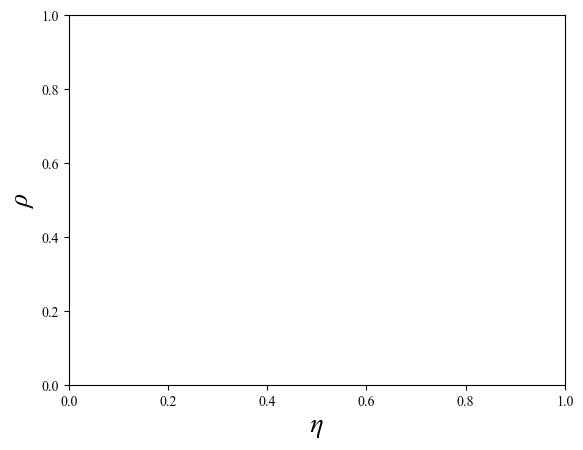

In [9]:
# For Hidden Symmetries 2026
fig,ax = plt.subplots()

# Poincare_plot plotting
ax.set_xlabel(r"$\eta$",fontsize=20)
ax.set_ylabel(r"$\rho$",fontsize=20)
# ax[j].set_xlim([0, 2 * np.pi])
ax.set_ylim([0, 1])
eta_points = []
s_points = []
for i in range(len(etas_all[1])):
    ax.scatter(
        np.array(etas_all[1][i],dtype=float),
        np.array((s_all[1][i])**0.5,dtype=float),
        marker="o",
        s=0.045,
        edgecolors="none",
        rasterized=True
    )

/var/folders/1s/jh18wdb5059c0177d80bb_xc0000gn/T/ipykernel_6909/1823810925.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(labels,fontsize=16)


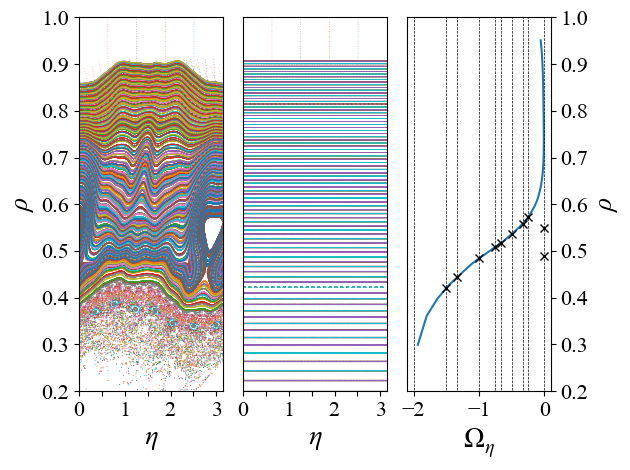

In [10]:
fig,ax = plt.subplots(nrows=1,ncols=3)

# Poincare_plot plotting
for j in [0,1]:
    ax[j].set_xlabel(r"$\eta$",fontsize=20)
    ax[j].set_ylabel(r"$\rho$",fontsize=20)
    # ax[j].set_xlim([0, 2 * np.pi])
    ax[j].set_ylim([0, 1])
    eta_points = []
    s_points = []
    for i in range(len(etas_all[j])):
        s_i = 0.25
        if any(x < 0.45 for x in s_all[j][i]):
            s_i = 0.6

        ax[j].scatter(
            np.array(etas_all[j][i],dtype=float),
            np.array((s_all[j][i]),dtype=float)**0.5,
            marker="o",
            s=s_i,
            edgecolors="none",
            rasterized=True
        )

ax[2].plot(omega_zetas,s_profs**0.25)
ax[2].set_xlabel(r'$\Omega_{\eta}$',fontsize=20)
ax[2].yaxis.set_label_position("right")
ax[2].yaxis.tick_right()
ax[2].set_ylabel(r'$\rho$',fontsize=20)
ax[2].set_ylim(0.2,1.0)
ax[2].set_xlim(-2.1,0.1)
# ax[2].legend(loc='upper left',bbox_to_anchor=(-1.26, 1.175))
ax[0].set_xlim([0,2*np.pi])
ax[1].set_xlim([0,2*np.pi])
ax[0].set_xticks([0, 1, 2, 3,4,5,6])
ax[0].set_xticklabels([str(0), '',str(1),'', str(2), '',str(3)],fontsize=16)
ax[1].set_xticks([0, 1, 2, 3,4,5,6])
ax[1].set_xticklabels([str(0), '',str(1),'', str(2), '',str(3)],fontsize=16)
colors_plot = ['bx','rx']
# m=0
for res in res_arr:
    ax[2].plot([res,res],[0,1],'k--',lw=0.5)
    i=0
    for j in range(0,len(s_profs)-1): # loop through each s
        res_dist_curr = omega_zetas[j] - res
        res_dist_next = omega_zetas[j+1] - res
        if np.sign(res_dist_curr)==np.sign(res_dist_next):
            continue # no res crossing found
        else: # res crossing found
            xs=np.linspace(omega_zetas[j],omega_zetas[j+1],100)
            ses = np.linspace(s_profs[j],s_profs[j+1],100)
            x_plot=999999999
            k_plot=0
            k=0
            for x in xs:
                if abs(x-res) < abs(x_plot-res):
                    x_plot = x
                    k_plot = k
                k+=1
            ax[2].plot(x_plot,(ses[k_plot])**0.25,'kx')
        # if abs(omega_zeta[j]) < zero_cross and m==0:
        #     zero_cross = omega_zeta[j]
        #     zero_cross_s = s_profs[i][j]
    i+=1
# m+=1

# Extra for Poincare Plot 1
ax[1].yaxis.set_visible(False)
ax[1].set_ylim([0.2,1.0])
ax[0].set_ylim([0.2,1.0])


# Add a b and c labels
labels = [item.get_text() for item in ax[0].get_yticklabels()]
# labels[-1]=''
ax[0].set_yticklabels(labels,fontsize=16)
labels = ['(a)', '(b)', '(c)']

# for i, a in enumerate(ax):
#     a.text(
#         0.35, 1.1, labels[i],
#         transform=a.transAxes,  # use axes coordinates (0–1)
#         fontsize=20,
#         fontweight='bold',
#         va='top', ha='left'
#     )

ax[2].set_xticks([0, -1, -2])
ax[2].tick_params(axis='x', labelsize=16)
ax[2].tick_params(axis='y', labelsize=16)

ax[2].plot(0,0.55,'kx')
ax[2].plot(0,0.49,'kx')


plt.tight_layout()
plt.savefig("poincare_omega_poster.pdf")
plt.savefig("poincare_omega_poster.png")

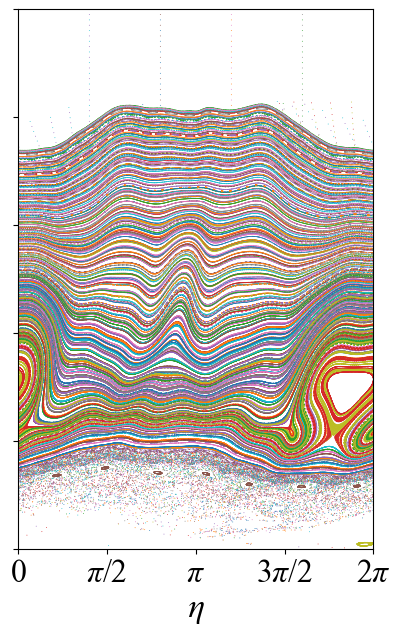

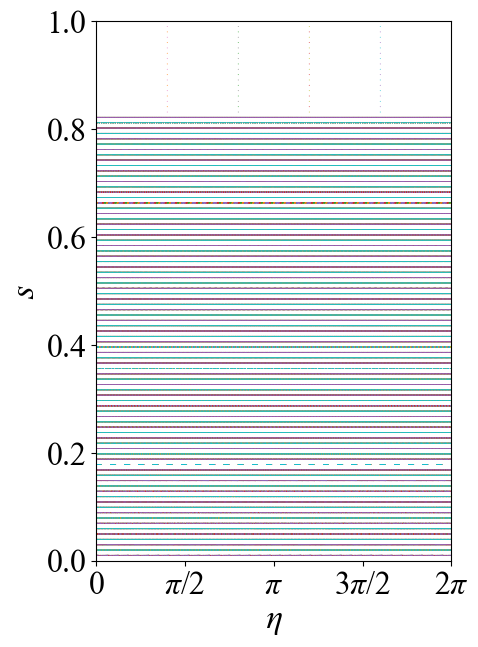

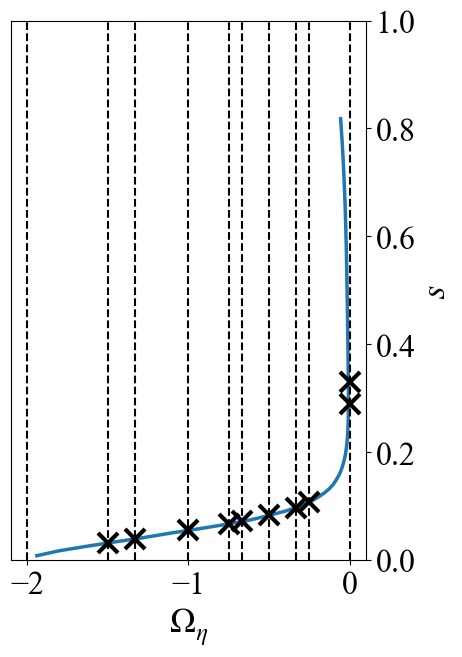

In [ ]:
# For Labbate et al., 2026 paper

FontSize = 25
label_kw = {"fontfamily": "Times New Roman", "fontsize": FontSize}
tick_labelsize = FontSize - 2

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "mathtext.fontset": "custom",
        "mathtext.rm": "Times New Roman",
        "mathtext.it": "Times New Roman:italic",
        "mathtext.bf": "Times New Roman:bold",
    }
)

# Identical axes box on every panel: figure taller than wide.
FIGSIZE = (5.0, 6.5)  # width, height
AX_BBOX = [0.17, 0.13, 0.71, 0.83]  # left, bottom, width, height

ms = 15
mew=3

fig1 = plt.figure(figsize=FIGSIZE)
ax1 = fig1.add_axes(AX_BBOX)
fig2 = plt.figure(figsize=FIGSIZE)
ax2 = fig2.add_axes(AX_BBOX)
fig3 = plt.figure(figsize=FIGSIZE)
ax3 = fig3.add_axes(AX_BBOX)

ax = [ax1,ax2,ax3]

# Poincare_plot plotting
for j in [0,1]:
    ax[j].set_xlabel(r"$\eta$",**label_kw)
    ax[j].set_ylabel(r"$s$",**label_kw)
    # ax[j].set_xlim([0, 2 * np.pi])
    ax[j].set_ylim([0, 1])
    eta_points = []
    s_points = []
    if j == 1:
        for i in range(len(etas_all[j])):
            s_i = 0.4
            # if any(x < 0.2 for x in s_all[j][i]):
            #     s_i = 1.0
            ax[j].scatter(
                np.array(etas_all[j][i],dtype=float),
                np.array((s_all[j][i]),dtype=float), # s not rho
                marker="o",
                s=s_i,
                edgecolors="none",
                rasterized=True
            )
    if j == 0: 
        for i in range(len(etas_all[j])):
            if any(x >= 0.4 for x in s_all[j][i]):                
                ax[j].scatter(
                    np.mod(np.array(etas_all[j][i],dtype=float),2*np.pi),
                    np.array((s_all[j][i]),dtype=float), # s not rho
                    marker="o",
                    s=0.4,
                    edgecolors="none",
                    rasterized=True
                )
        for i in range(len(etas_all_full)):
            if any(x < 0.4 for x in s_all_full[i]):
                ax[j].scatter(
                    np.mod(np.array(etas_all_full[i][1:],dtype=float),2*np.pi),
                    np.array((s_all_full[i][1:]),dtype=float), # s not rho
                    marker="o",
                    s=0.4,
                    edgecolors="none",
                    rasterized=True
                )


ax[2].plot(omega_zetas,s_profs,lw=2.5)
ax[2].set_xlabel(r'$\Omega_{\eta}$',**label_kw)
ax[2].yaxis.set_label_position("right")
ax[2].yaxis.tick_right()
ax[2].set_ylabel(r'$s$',**label_kw)
ax[2].set_ylim(0.0,1.0)
ax[2].set_xlim(-2.1,0.1)
# ax[2].legend(loc='upper left',bbox_to_anchor=(-1.26, 1.175))
ax[0].set_xlim([0,2*np.pi])
ax[1].set_xlim([0,2*np.pi])
ax[0].set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax[0].set_xticklabels([f'$0$', f'$\pi/2$', f'$\pi$', f'$3\pi/2$', f'$2\pi$'],fontsize=tick_labelsize)
ax[1].set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax[1].set_xticklabels([f'$0$', f'$\pi/2$', f'$\pi$', f'$3\pi/2$', f'$2\pi$'],fontsize=tick_labelsize)
colors_plot = ['bx','rx']
# m=0
for res in res_arr:
    ax[2].plot([res,res],[0,1],'k--',lw=1.5)
    i=0
    for j in range(0,len(s_profs)-1): # loop through each s
        res_dist_curr = omega_zetas[j] - res
        res_dist_next = omega_zetas[j+1] - res
        if np.sign(res_dist_curr)==np.sign(res_dist_next):
            continue # no res crossing found
        else: # res crossing found
            xs=np.linspace(omega_zetas[j],omega_zetas[j+1],100)
            ses = np.linspace(s_profs[j],s_profs[j+1],100)
            x_plot=999999999
            k_plot=0
            k=0
            for x in xs:
                if abs(x-res) < abs(x_plot-res):
                    x_plot = x
                    k_plot = k
                k+=1
            ax[2].plot(x_plot,(ses[k_plot]),'kx',markersize=ms,markeredgewidth=mew)
        # if abs(omega_zeta[j]) < zero_cross and m==0:
        #     zero_cross = omega_zeta[j]
        #     zero_cross_s = s_profs[i][j]
    i+=1
# m+=1

# Extra for Poincare Plot 1
# ax[1].yaxis.set_visible(False)
for a in ax:
    a.set_ylim([0.0,1.0])
    a.set_yticks([0, 0.2,0.4,0.6,0.8,1.0])

# Keep y-ticks on ax[0] but hide their labels, and remove its y-axis label.
ax[0].set_yticklabels(['','','','','',''])
ax[0].set_ylabel('')


# Add a b and c labels
# labels = [item.get_text() for item in ax[0].get_yticklabels()]
# labels[-1]=''
# ax[0].set_yticklabels(labels,fontsize=16)
# labels = ['(a)', '(b)', '(c)']

# for i, a in enumerate(ax):
#     a.text(
#         0.35, 1.1, labels[i],
#         transform=a.transAxes,  # use axes coordinates (0–1)
#         fontsize=20,
#         fontweight='bold',
#         va='top', ha='left'
#     )

ax[2].set_xticks([0, -1, -2])
ax[2].tick_params(axis='x', labelsize=tick_labelsize)
for a in ax:
    a.tick_params(axis='y', labelsize=tick_labelsize)


ax[2].plot(0,0.33,'kx',markersize=ms,markeredgewidth=mew)
ax[2].plot(0,0.29,'kx',markersize=ms,markeredgewidth=mew)
# ax[2].plot(-2,0.005,'kx',markersize=ms,markeredgewidth=mew)



# plt.tight_layout()
# plt.savefig("poincare_omega_poster.pdf")
# plt.savefig("poincare_omega_poster.png")
# fig1.tight_layout()
# fig2.tight_layout()
# fig3.tight_layout()

fig1.savefig("For Publish/subfig_pert.pdf")
fig2.savefig("For Publish/subfig_unpert.pdf")
fig3.savefig("For Publish/subfig_pertunpertomega.pdf")

In [ ]:
import warnings

import desc.io
from desc.grid import LinearGrid


def compute_qs_two_term_profile(
    eq=None,
    eq_filename=None,
    rhos=None,
    s=None,
    helicity=(1, 0),
    normalize=True,
    M=None,
    N=None,
):
    """Compute the DESC two-term QS metric f_C on flux surfaces.

    This evaluates the quasi-symmetry flux-function error used by
    ``QuasisymmetryTwoTerm``, surface-averaged on each requested flux surface.

    Parameters
    ----------
    eq : desc.equilibrium.Equilibrium, optional
        Equilibrium to evaluate. If omitted, ``eq_filename`` is loaded.
    eq_filename : str, optional
        Path to a DESC equilibrium ``.h5`` file.
    rhos : array_like, optional
        Radial coordinate rho = sqrt(s). Provide either ``rhos`` or ``s``.
    s : array_like, optional
        Normalized toroidal flux s = rho^2.
    helicity : tuple of int
        QS helicity (M, N); use (1, 0) for QA and (1, eq.NFP) for QH.
    normalize : bool
        If True, return <|f_C|> / <B>^3 on each surface.
    M, N : int, optional
        Poloidal/toroidal resolution for the evaluation grid.

    Returns
    -------
    rhos : ndarray
        Sorted radial coordinates used in the calculation.
    f_C : ndarray
        Two-term QS metric on each flux surface.
    """
    if eq is None:
        if eq_filename is None:
            raise ValueError("Provide either eq or eq_filename.")
        eq = desc.io.load(eq_filename)

    if rhos is None:
        if s is None:
            raise ValueError("Provide either rhos or s.")
        rhos = np.sqrt(np.asarray(s, dtype=float))
    rhos = np.sort(np.asarray(rhos, dtype=float))

    if M is None:
        M = 2 * eq.M_grid
    if N is None:
        N = 2 * eq.N_grid

    grid = LinearGrid(M=M, N=N, NFP=eq.NFP, rho=rhos, sym=eq.sym)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        bdata = eq.compute(["|B|", "sqrt(g)"])
    B0 = np.mean(bdata["|B|"] * bdata["sqrt(g)"]) / np.mean(bdata["sqrt(g)"])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        data = eq.compute(["sqrt(g)", "f_C"], grid=grid, helicity=helicity)

    sqrtg = grid.meshgrid_reshape(data["sqrt(g)"], "rtz")
    f_C = grid.meshgrid_reshape(data["f_C"], "rtz")
    f_C_prof = np.mean(np.abs(f_C) * sqrtg, axis=(1, 2)) / np.mean(sqrtg, axis=(1, 2))
    if normalize:
        f_C_prof = f_C_prof / B0**3

    return rhos, f_C_prof


# QA helicity for G1600: (M, N) = (1, 0)
rhos = (np.linspace(0.1, 0.9, 50)) ** (1 / 2)
_, obj_out = compute_qs_two_term_profile(
    eq_filename="../inputs/equil_G1600_DESC_fixed.h5",
    rhos=rhos,
    helicity=(1, 0),
)
obj_out = obj_out / np.max(obj_out)

fig1, ax1 = plt.subplots()
# Poincare_plot plotting
ax1.set_xlabel(r"$\eta$")
ax1.set_ylabel(r"$s$")
# ax[j].set_xlim([0, 2 * np.pi])
ax1.set_ylim([0, 1])
eta_points = []
s_points = []

Y = rhos**2  # plotting s
X = np.linspace(0, 2 * np.pi, 5)
Z = np.transpose(np.tile(obj_out, (5, 1)))
cs = ax1.contourf(X, Y, Z, cmap="Blues")
fig1.colorbar(cs, ax=ax1, label="Objective Function Value")

for i in range(len(etas_all[0])):
    ax1.scatter(
        np.array(etas_all[0][i], dtype=float),
        np.array(s_all[0][i], dtype=float),
        marker="o",
        s=0.3,
        edgecolors="none",
        rasterized=True,
    )

# plt.savefig("objective_poincare_overlay.pdf")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm, colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

# -----------------------
# Example / your setup
# -----------------------
fig1, ax1 = plt.subplots(figsize=(6, 4))

ax1.set_xlabel(r"$\eta$",fontsize=20)
ax1.set_ylabel(r"$\rho$",fontsize=20)
ax1.set_ylim([0, 1])

obj_out = np.load("forpoinc_QI.npy") 
# obj_out = obj_out / np.max(obj_out)

rhos = (np.linspace(0.1, 0.9, 50)) ** (1/2)
Y = rhos
X = np.linspace(0, 2*np.pi, 5)
Z = np.transpose(np.tile(obj_out, (5, 1)))  # shape (50, 5)

# -----------------------
# Shared colormap + normalization
# -----------------------
cmap = cm.get_cmap('Blues')
norm = colors.Normalize(vmin=0, vmax=1)

# -----------------------
# Contour plot (uses shared cmap/norm)
# -----------------------
cs = ax1.contourf(X, Y, Z, cmap=cmap, norm=norm)
cbar = fig1.colorbar(cs, ax=ax1, label=r"$f^i(\rho)$")
cbar.set_label(r"$f^i(\rho)$", rotation=0, labelpad=23, fontsize=18)

# (Optional) scatter overlay
for i in range(len(etas_all[0])):
    for j in range(0,len(s_all[0][i])):
        if s_all[0][i][j] < 0:
            s_all[0][i][j] = 0
            # etas_all[0][i][j]
    ax1.scatter(np.array(etas_all[0][i],dtype=float),
                (np.array(s_all[0][i],dtype=float))**0.5,
                marker="o", s=0.3, edgecolors="none", rasterized=True)

# -----------------------
# Add the 1D color strip to the right
# -----------------------
divider = make_axes_locatable(ax1)
cax_strip = divider.append_axes("right", size="5%", pad=0.1)
ax1.set_ylim([0.2,1.0])


# reshape obj_out → vertical strip
obj_out_2d = obj_out.reshape(-1, 1)
# cax_strip.imshow(
#     obj_out_2d,
#     aspect='auto',
#     cmap=cmap,
#     norm=norm,           # 🔹 ensures colors match contour plot
#     origin='lower',
#     extent=(0, 1, *ax1.get_ylim())
# )
N = obj_out_2d.shape[0]

# Compute edges for the non-uniform rhos (length N+1)
# midpoints between adjacent rhos
midpoints = 0.5 * (rhos[:-1] + rhos[1:])          # length N-1
# edges: extrapolate outward for the first and last edges
y_edges = np.empty(N + 1)
y_edges[1:-1] = midpoints
y_edges[0] = rhos[0] - (midpoints[0] - rhos[0])
y_edges[-1] = rhos[-1] + (rhos[-1] - midpoints[-1])
x_edges = np.array([0.0, 1.0])  # length 2 -> nx = 1

pcm = cax_strip.pcolormesh(x_edges, y_edges, obj_out_2d,
                           cmap=cmap, norm=norm, shading='flat')
cax_strip.set_ylim([0.2,1.0])

# clean up the strip axis
cax_strip.set_xticks([])
# cax_strip.set_ylabel("ρ² (s)")
# cax_strip.yaxis.set_label_position("right")
# cax_strip.yaxis.tick_right()
cax_strip.yaxis.set_visible(False)

ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16)
cbar.ax.tick_params(labelsize=15)
cbar.set_ticks(np.linspace(0, 1.0, 6))


plt.tight_layout()
plt.savefig("objective_poincare_overlay.pdf")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Imports for Poincares
etas_all = np.load('G1600_trapped_poincare_Bc6.2.png_etas_.npy',allow_pickle=True)
s_all = np.load('G1600_trapped_poincare_Bc6.2.png_s1_.npy',allow_pickle=True)

fig1,ax1 = plt.subplots()
# Poincare_plot plotting
ax1.set_xlabel(r"$\eta$")
ax1.set_ylabel(r"$s$")
# ax[j].set_xlim([0, 2 * np.pi])
# ax1.set_ylim([0.2, 0.5])
eta_points = []
s_points = []
# ax1.set_yticks([])
# ax1.set_yticklabels([])
ax1.set_xlim([0,2*np.pi])

for i in range(len(etas_all)):
    ax1.scatter(
        np.array(etas_all[i],dtype=float),
        np.array(s_all[i],dtype=float),
        marker="o",
        s=0.8,
        edgecolors="none",
        rasterized=True
    )
plt.savefig('poincare_fake_diff.png')